In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [6]:
df = pd.read_csv('imdb_data (1).csv')

#  **(1) Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.**

In [7]:
df['profit'] = df['revenue'] - df['budget']
top_movie = df.loc[df['profit'].idxmax()]

print("Movie Name:", top_movie['title'])
crew = ast.literal_eval(top_movie['crew'])

director = [person['name'] for person in crew if person['job'] == 'Director']
print("Director:", director)
producers = [person['name'] for person in crew if person['job'] == 'Producer']
print("Producers:", producers)
cast = ast.literal_eval(top_movie['cast'])
actors = [person['name'] for person in cast[:10]]  # top 10 actors

print("Actors:", actors)

Movie Name: Furious 7
Director: ['James Wan']
Producers: ['Vin Diesel', 'Neal H. Moritz', 'Michael Fottrell', 'Brandon Birtell']
Actors: ['Vin Diesel', 'Paul Walker', 'Dwayne Johnson', 'Michelle Rodriguez', 'Tyrese Gibson', 'Ludacris', 'Jordana Brewster', 'Djimon Hounsou', 'Tony Jaa', 'Ronda Rousey']


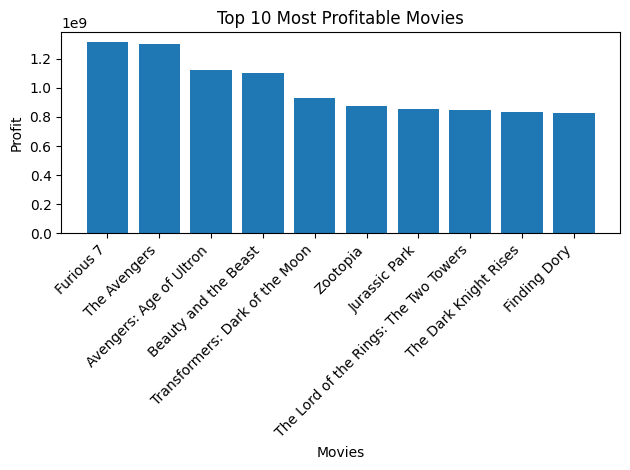

In [12]:
plt.figure()
plt.bar(top10['title'], top10['profit'])
plt.xlabel('Movies')
plt.ylabel('Profit')
plt.title('Top 10 Most Profitable Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## **(2)  This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?**

In [14]:
df = df[df['budget'] > 0]
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']
roi_by_language = df.groupby('original_language')['ROI'].mean()
top_language = roi_by_language.idxmax()
top_value = roi_by_language.max()

print("Language with highest average ROI:", top_language)
print("Average ROI:", top_value)

Language with highest average ROI: ko
Average ROI: 381794.10228078865


# **(3) Find out the unique genres of movies in this dataset.**

In [17]:
unique_genres = set()
for item in df['genres']:
    if pd.notnull(item):
        genre_list = ast.literal_eval(item)
        for genre in genre_list:
            unique_genres.add(genre['name'])
unique_genres = sorted(unique_genres)

print("Unique Genres:")
print(unique_genres)

Unique Genres:
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


# **(4)Make a table of all the producers and directors of each movie. find the top 3 producers who have produced movies with the highest average ROI.**

In [22]:
def get_names(x, role):
    if pd.isna(x):
        return []
    return [i['name'] for i in ast.literal_eval(x) if i['job'] == role]
df['Director'] = df['crew'].apply(lambda x: get_names(x, 'Director'))
df['Producer'] = df['crew'].apply(lambda x: get_names(x, 'Producer'))
table = df[['title', 'Director', 'Producer']]
print(table.head())

df = df[df['budget'] > 0]
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']

df2 = df.explode('Producer')
top3 = (df2.groupby('Producer')['ROI'].mean()
    .sort_values(ascending=False).head(3))
print("\nTop 3 Producers:")
print(top3)

                                      title           Director  \
0                    Hot Tub Time Machine 2       [Steve Pink]   
1  The Princess Diaries 2: Royal Engagement   [Garry Marshall]   
2                                  Whiplash  [Damien Chazelle]   
3                                   Kahaani      [Sujoy Ghosh]   
5    Pinocchio and the Emperor of the Night   [Hal Sutherland]   

                                            Producer  
0                                     [Andrew Panay]  
1  [Whitney Houston, Mario Iscovich, Debra Martin...  
2  [David Lancaster, Michel Litvak, Jason Blum, H...  
3                                      [Sujoy Ghosh]  
5                                                 []  

Top 3 Producers:
Producer
Ji Sang-yong    4197475.625
Lee Eun-ha      4197475.625
Jang Jin        4197475.625
Name: ROI, dtype: float64


# **(5) Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.**

In [34]:
df['Actors'] = df['cast'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if pd.notna(x) else [])
df = df.explode('Actors')
top_actor = df['Actors'].value_counts().idxmax()
print("Top Actor:", top_actor)

df = df[df['Actors'] == top_actor]

genres = df['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if pd.notna(x) else [])

print("Top Genres:", genres.explode().value_counts().head())
df = df[df['budget'] > 0]
print("Average Profit:", ((df['revenue'] - df['budget']).mean()))

Top Actor: Samuel L. Jackson
Top Genres: genres
Action             16
Crime              12
Adventure          11
Thriller           10
Science Fiction     9
Name: count, dtype: int64
Average Profit: 268641625.64


# **(6) Top 3 directors prefer which actors the most?**

In [39]:
import pandas as pd, ast
df = pd.read_csv("imdb_data (1).csv")
df['crew'] = df['crew'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['cast'] = df['cast'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df['director'] = df['crew'].apply(lambda c: next((m['name'] for m in c if m.get('job')=='Director'), None))
top3 = df['director'].value_counts().head(3).index
for d in top3:
    actors = [a['name'] for c in df[df['director']==d]['cast'] for a in c]
    print(f"\nDirector: {d}")
    print(pd.Series(actors).value_counts().head(5))


Director: Clint Eastwood
Clint Eastwood     8
Laura Linney       2
Doug McGrath       2
Mara Corday        2
Annie O'Donnell    2
Name: count, dtype: int64

Director: Ron Howard
Clint Howard         7
Rance Howard         6
James Ritz           4
Mark Wheeler         2
Max Elliott Slade    2
Name: count, dtype: int64

Director: Steven Spielberg
Harrison Ford       3
Pat Roach           2
Tom Hanks           2
Richard Dreyfuss    2
Steven Spielberg    2
Name: count, dtype: int64
